In [1]:
from random import randrange
from sympy.ntheory import factorint
from tools import *

import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import pickle
import torch as tn
import torchtt as tt

In [2]:
#mesh_type = 'quad'
mesh_type = 'hex'
#mesh_type = 'sphr'
filename = f'mpas/out_{mesh_type}.nc'
ds = nc.Dataset(filename)
#print(data)

ncells = ds.dimensions['nCells'].size
nedges = ds.dimensions['nEdges'].size
print(f'ncells = {ncells}')
print(f'nedges = {nedges}')

ntimeLevels = ds.dimensions['Time'].size
print(f'ntimeLevels = {ntimeLevels}')

ncells = 56112
nedges = 168336
ntimeLevels = 13


In [3]:
hh_cell = ds.variables['layerThickness'][:, :, 0]
uu_edge = ds.variables['normalVelocity'][:, :, 0]

angleEdge = ds.variables['angleEdge'][:]
angles = np.unique(np.round(angleEdge, decimals=13))
print(angles)
u_angles = [angles[0], angles[3]]
v_angles = [angles[1], angles[4]]
w_angles = [angles[2], angles[5]]

u_inds = [ind for ind in range(nedges) if np.round(angleEdge[ind], decimals=13) in u_angles]
v_inds = [ind for ind in range(nedges) if np.round(angleEdge[ind], decimals=13) in v_angles]
w_inds = [ind for ind in range(nedges) if np.round(angleEdge[ind], decimals=13) in w_angles]

nedges_u = len(uu_edge[0, u_inds])
nedges_v = len(uu_edge[0, v_inds])
nedges_w = len(uu_edge[0, w_inds])
print(f'nedges_u = {nedges_u}')
print(f'nedges_v = {nedges_v}')
print(f'nedges_w = {nedges_w}')

[0.         1.04719755 2.0943951  3.14159265 4.1887902  5.23598776]
nedges_u = 56112
nedges_v = 56112
nedges_w = 56112


In [4]:
prime_factors_cell = list( factorint(ncells).items() )
prime_factors_edge = list( factorint(nedges).items() )
prime_factors_edge_u = list( factorint(nedges_u).items() )
prime_factors_edge_v = list( factorint(nedges_v).items() )
prime_factors_edge_w = list( factorint(nedges_w).items() )
print(f'prime_factors_cell = {prime_factors_cell}')
print(f'prime_factors_edge = {prime_factors_edge}')
print(f'prime_factors_edge_u = {prime_factors_edge_u}')
print(f'prime_factors_edge_v = {prime_factors_edge_v}')
print(f'prime_factors_edge_w = {prime_factors_edge_w}')

tt_tens_shape_cell = []
for factor in prime_factors_cell:
    #tt_tens_shape_cell += [ factor[0] ] * factor[1]
    tt_tens_shape_cell += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge = []
for factor in prime_factors_edge:
    #tt_tens_shape_edge += [ factor[0] ] * factor[1]
    tt_tens_shape_edge += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge_u = []
for factor in prime_factors_edge_v:
    #tt_tens_shape_edge_u += [ factor[0] ] * factor[1]
    tt_tens_shape_edge_u += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge_v = []
for factor in prime_factors_edge_v:
    #tt_tens_shape_edge_v += [ factor[0] ] * factor[1]
    tt_tens_shape_edge_v += [ factor[0] ** factor[1] ]
# END for

tt_tens_shape_edge_w = []
for factor in prime_factors_edge_w:
    #tt_tens_shape_edge_w += [ factor[0] ] * factor[1]
    tt_tens_shape_edge_w += [ factor[0] ** factor[1] ]
# END for

print(f'tt_tens_shape_cell = {tt_tens_shape_cell}')
print(f'tt_tens_shape_edge = {tt_tens_shape_edge}')
print(f'tt_tens_shape_edge_u = {tt_tens_shape_edge_u}')
print(f'tt_tens_shape_edge_v = {tt_tens_shape_edge_v}')
print(f'tt_tens_shape_edge_w = {tt_tens_shape_edge_w}')

prime_factors_cell = [(2, 4), (3, 1), (7, 1), (167, 1)]
prime_factors_edge = [(2, 4), (3, 2), (7, 1), (167, 1)]
prime_factors_edge_u = [(2, 4), (3, 1), (7, 1), (167, 1)]
prime_factors_edge_v = [(2, 4), (3, 1), (7, 1), (167, 1)]
prime_factors_edge_w = [(2, 4), (3, 1), (7, 1), (167, 1)]
tt_tens_shape_cell = [16, 3, 7, 167]
tt_tens_shape_edge = [16, 9, 7, 167]
tt_tens_shape_edge_u = [16, 3, 7, 167]
tt_tens_shape_edge_v = [16, 3, 7, 167]
tt_tens_shape_edge_w = [16, 3, 7, 167]


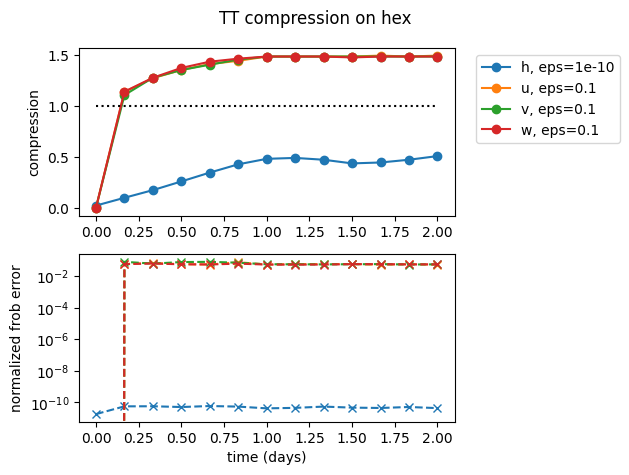

In [5]:
eps_h = 1e-10
eps_u = 1e-1
eps_v = 1e-1
eps_w = 1e-1
data = [{'var': hh_cell[:, :], 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uu_edge[:, u_inds], 'shape': tt_tens_shape_edge_u, 'eps': eps_u, 'name': 'u'},
        {'var': uu_edge[:, v_inds], 'shape': tt_tens_shape_edge_v, 'eps': eps_v, 'name': 'v'},
        {'var': uu_edge[:, w_inds], 'shape': tt_tens_shape_edge_w, 'eps': eps_w, 'name': 'w'}]

compression, err = get_compression_data(data)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_{eps_v}_{eps_w}.png')

In [6]:
h_shuffle = np.copy(hh_cell[-1, :])
u_shuffle = np.copy(uu_edge[-1, u_inds])
v_shuffle = np.copy(uu_edge[-1, v_inds])
w_shuffle = np.copy(uu_edge[-1, w_inds])

nshuffles = 100
h_final_compression = np.zeros(nshuffles)
u_final_compression = np.zeros(nshuffles)
v_final_compression = np.zeros(nshuffles)
w_final_compression = np.zeros(nshuffles)
for i in range(nshuffles):
    np.random.shuffle(h_shuffle)
    np.random.shuffle(u_shuffle)
    np.random.shuffle(v_shuffle)
    np.random.shuffle(w_shuffle)

    h_tt = tt.TT(h_shuffle, tt_tens_shape_cell, eps=eps_h)
    u_tt = tt.TT(u_shuffle, tt_tens_shape_edge_u, eps=eps_u)
    v_tt = tt.TT(v_shuffle, tt_tens_shape_edge_v, eps=eps_v)
    w_tt = tt.TT(w_shuffle, tt_tens_shape_edge_w, eps=eps_w)

    h_final_compression[i], _ = calc_compression(h_tt)
    u_final_compression[i], _ = calc_compression(u_tt)
    v_final_compression[i], _ = calc_compression(v_tt)
    w_final_compression[i], _ = calc_compression(w_tt)
# END for 

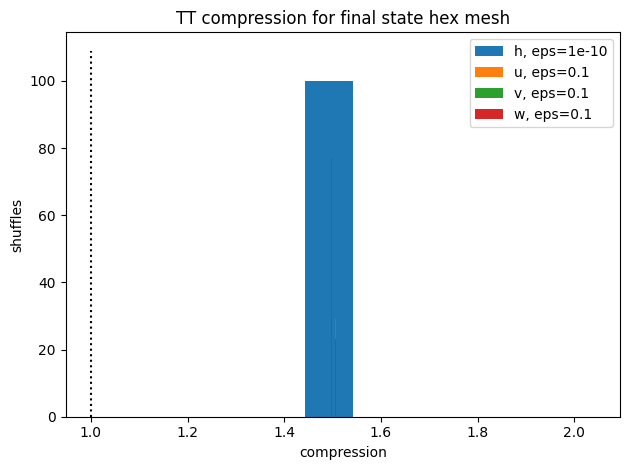

In [7]:
fig, ax = plt.subplots(tight_layout=True)
#print(u_final_compression)
#print(h_final_compression)
#print(v_final_compression)
ax.hist(h_final_compression, label=f'h, eps={eps_h}')
ax.hist(u_final_compression, label=f'u, eps={eps_u}')
ax.hist(v_final_compression, label=f'v, eps={eps_v}')
ax.hist(w_final_compression, label=f'w, eps={eps_w}')
ax.plot(np.ones(int(1.1 * nshuffles)), np.arange(int(1.1 * nshuffles)), ':k')
ax.set(xlabel='compression',
       ylabel='shuffles',
       title=f'TT compression for final state {mesh_type} mesh')
ax.legend()
plt.savefig(f'compression_shuffle_{mesh_type}.png')
plt.show()

In [8]:
xmin = 0
xmax = 40110000
ymin = 0
ymax = 17459100

xEdge = ds.variables['xEdge'][:]
yEdge = ds.variables['yEdge'][:]



u_ind_root = 91846 - 1
u_ind_1 = 109981 - 1
u_ind_2 = 132305 - 1
u_start_x = xEdge[u_ind_root]
u_start_y = yEdge[u_ind_root]
dx_u = xEdge[u_ind_1] - u_start_x
dy_u = yEdge[u_ind_2] - u_start_y

# loop to sort u edges
if 1:
    print('Sorting inds for u...')
    sorted_inds_u = []
    row = 0
    for y in np.arange(u_start_y, ymax + dy_u, dy_u):
        row += 1
        for x in np.arange(u_start_x, xmax + dx_u, dx_u):
            if row % 2 == 0: x += dx_u / 2
            try:
                ind = np.where(np.logical_and(np.isclose(xEdge, x), np.isclose(yEdge, y)))[0][0]
                sorted_inds_u.append(ind)
            except:
                #print(x, y)
                #print(np.any(np.logical_and(np.isclose(xEdge, x), np.isclose(yEdge, y))))
                pass
            # END try
        # END for
    # END for
# END if

print(f'u edges found = {len(sorted_inds_u)}')
print(f'u angles = {np.unique(np.round(angleEdge[sorted_inds_u], decimals=13))}')


v_ind_root = 163708 - 1
v_ind_1 = 100192 - 1
v_ind_2 = 99126 - 1
v_start_x = xEdge[v_ind_root]
v_start_y = yEdge[v_ind_root]
dx_v = xEdge[v_ind_1] - v_start_x
dy_v = yEdge[v_ind_2] - v_start_y

# loop to sort v edges
if 1:
    print('Sorting inds for v...')
    sorted_inds_v = []
    row = 0
    for y in np.arange(v_start_y, ymax + dy_v, dy_v):
        row += 1
        for x in np.arange(v_start_x, xmax + dx_v, dx_v):
            if row % 2 == 0: x += dx_u / 2
            try:
                ind = np.where(np.logical_and(np.isclose(xEdge, x), np.isclose(yEdge, y)))[0][0]
                sorted_inds_v.append(ind)
            except:
                #print(x, y)
                #print(np.any(np.logical_and(np.isclose(xEdge, x), np.isclose(yEdge, y))))
                pass
            # END try
        # END for
    # END for
# END if

print(f'v edges found = {len(sorted_inds_v)}')
print(f'v angles = {np.unique(np.round(angleEdge[sorted_inds_v], decimals=13))}')


w_ind_root = 109545 - 1
w_ind_1 = 103344 - 1
w_ind_2 = 111176 - 1
w_start_x = xEdge[w_ind_root]
w_start_y = yEdge[w_ind_root]
dx_w = xEdge[w_ind_2] - xEdge[w_ind_1]
dy_w = yEdge[w_ind_2] - w_start_y

# loop to sort w edges
if 1:
    print('Sorting inds for w...')
    sorted_inds_w = []
    row = 0
    for y in np.arange(w_start_y, ymax + dy_w, dy_w):
        row += 1
        for x in np.arange(w_start_x, xmax + dx_w, dx_w):
            if row % 2 == 0: x -= dx_w / 2
            try:
                ind = np.where(np.logical_and(np.isclose(xEdge, x), np.isclose(yEdge, y)))[0][0]
                sorted_inds_w.append(ind)
            except:
                #print(x, y)
                #print(np.any(np.logical_and(np.isclose(xEdge, x), np.isclose(yEdge, y))))
                pass
            # END try
        # END for
    # END for
# END if

print(f'w edges found = {len(sorted_inds_w)}')
print(f'w angles = {np.unique(np.round(angleEdge[sorted_inds_w], decimals=13))}')

Sorting inds for u...
u edges found = 56112
u angles = [0.         3.14159265]
Sorting inds for v...
v edges found = 56112
v angles = [1.04719755 4.1887902 ]
Sorting inds for w...
w edges found = 56112
w angles = [2.0943951  5.23598776]


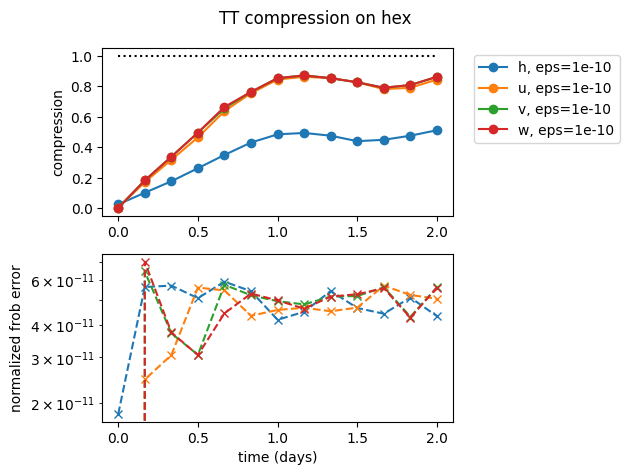

In [9]:
eps_h = 1e-10
eps_u = 1e-10
eps_v = 1e-10
eps_w = 1e-10
data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uu_edge[:, sorted_inds_u], 'shape': tt_tens_shape_edge_u, 'eps': eps_u, 'name': 'u'},
        {'var': uu_edge[:, sorted_inds_v], 'shape': tt_tens_shape_edge_v, 'eps': eps_v, 'name': 'v'},
        {'var': uu_edge[:, sorted_inds_w], 'shape': tt_tens_shape_edge_w, 'eps': eps_w, 'name': 'w'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_{eps_v}_SORTED.png')

compression_primepow_shape = compression

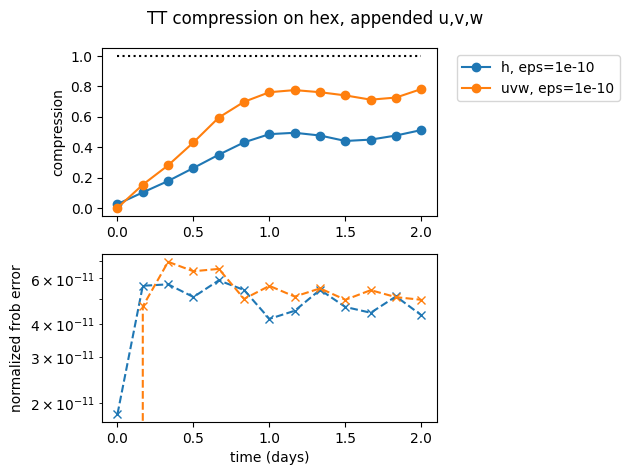

In [10]:
uv_sorted = np.append(uu_edge[:, sorted_inds_u], uu_edge[:, sorted_inds_v], axis=1)
uvw_sorted = np.append(uv_sorted, uu_edge[:, sorted_inds_w], axis=1)

eps_h = 1e-10
eps_u = 1e-10
data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uvw_sorted, 'shape': tt_tens_shape_edge, 'eps': eps_u, 'name': 'uvw'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, appended u,v,w',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_appended.png')

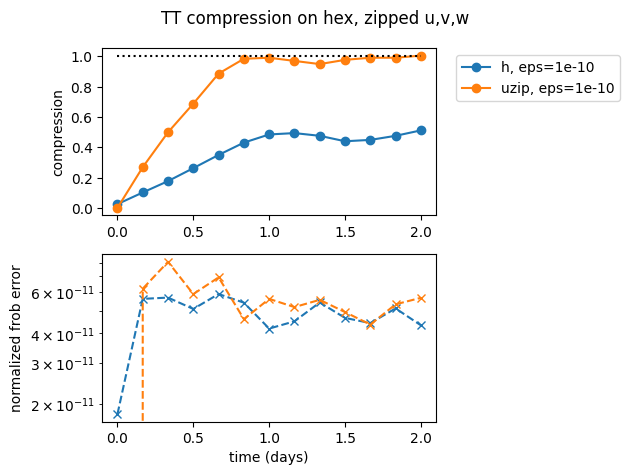

In [11]:
u_shape = uu_edge[:, sorted_inds_u].shape
v_shape = uu_edge[:, sorted_inds_v].shape
w_shape = uu_edge[:, sorted_inds_w].shape
uvw_zip = np.ma.empty([u_shape[0], u_shape[1] + v_shape[1] + w_shape[1]])

inds = np.arange(uvw_zip.shape[1])
uvw_zip[:, inds % 3 == 0] = np.ma.copy(uu_edge[:, sorted_inds_u])
uvw_zip[:, inds % 3 == 1] = np.ma.copy(uu_edge[:, sorted_inds_v])
uvw_zip[:, inds % 3 == 2] = np.ma.copy(uu_edge[:, sorted_inds_w])

eps_h = 1e-10
eps_u = 1e-10
data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uvw_zip, 'shape': tt_tens_shape_edge, 'eps': eps_u, 'name': 'uzip'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, zipped u,v,w',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_zipped.png')

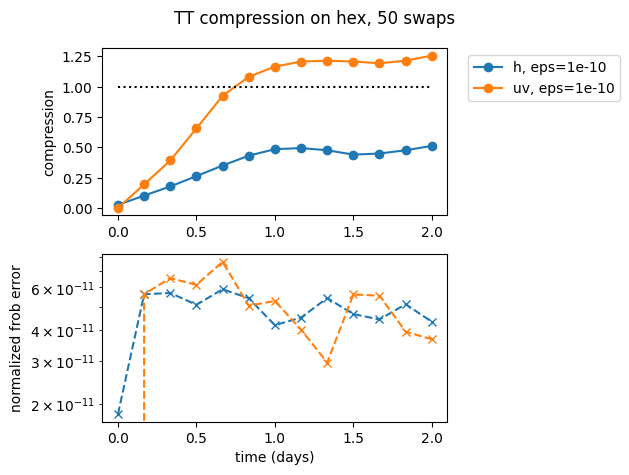

In [12]:
def rand_swap(a):
    max_ind = a.shape[1]
    ind1 = randrange(max_ind)
    ind2 = randrange(max_ind)
    a[:, [ind1, ind2]] = a[:, [ind2, ind1]]
# END rand_swap()

eps_h = 1e-10
eps_u = 1e-10
uvw_shuffle = np.ma.copy(uvw_sorted)

nswaps = 50
for i in range(nswaps):
    rand_swap(uvw_shuffle)
# END for

data = [{'var': hh_cell, 'shape': tt_tens_shape_cell, 'eps': eps_h, 'name': 'h'},
        {'var': uvw_shuffle, 'shape': tt_tens_shape_edge, 'eps': eps_u, 'name': 'uv'}]
#print(f'eps_h = {eps_h}', f'eps_u = {eps_u}', f'eps_v = {eps_v}')

compression, err = get_compression_data(data)
#print(f'h_compression = {compression[0]}')
#print(f'u_compression = {compression[1]}')
#print(f'v_compression = {compression[2]}')

make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, {nswaps} swaps',
              f'compression_{mesh_type}_{eps_h}_{eps_u}_{nswaps}swaps.png')

In [13]:
N = 334
M = ncells // N

mat_shape = [M, N]
print(mat_shape)

[168, 334]


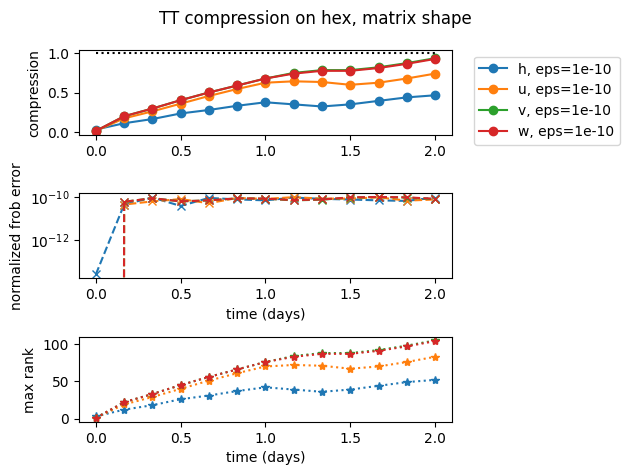

[ 3. 12. 18. 26. 31. 37. 42. 39. 36. 39. 44. 49. 52.]
[ 1. 19. 29. 40. 51. 61. 70. 72. 71. 67. 70. 76. 83.]
[  1.  22.  33.  45.  56.  66.  76.  84.  88.  88.  92.  98. 105.]
[  1.  22.  33.  45.  56.  66.  76.  83.  87.  87.  91.  97. 104.]


In [14]:
eps_h = 1e-10
eps_u = 1e-10
eps_v = 1e-10
eps_w = 1e-10
data = [{'var': hh_cell, 'shape': mat_shape, 'eps': eps_h, 'name': 'h'},
        {'var': uu_edge[:, sorted_inds_u], 'shape': mat_shape, 'eps': eps_u, 'name': 'u'},
        {'var': uu_edge[:, sorted_inds_v], 'shape': mat_shape, 'eps': eps_v, 'name': 'v'},
        {'var': uu_edge[:, sorted_inds_w], 'shape': mat_shape, 'eps': eps_w, 'name': 'w'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape',
              f'compression_{mesh_type}_mat_shape_{eps_h}.png',
              rank=rank)
print(rank[0])
print(rank[1])
print(rank[2])
print(rank[3])

compression_mat_shape = compression

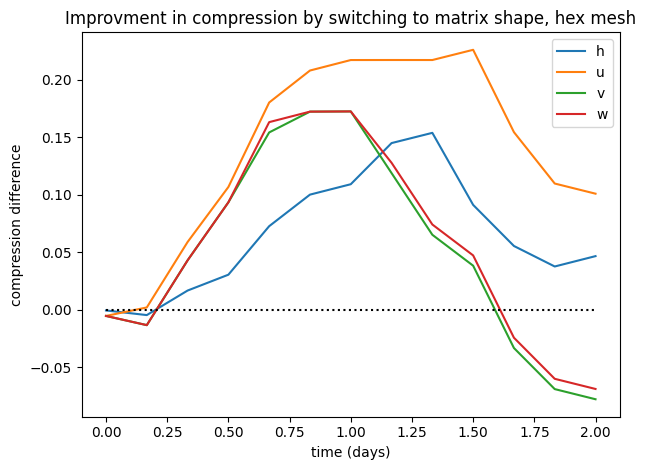

In [15]:
# NOTE -- FOR THIS PLOT TO MAKE SENSE MAKE SURE THAT
# THE EPS VALUES FOR BOTH COMPRESSION ARRAYS ARE THE SAME

time = 4 * np.arange(ntimeLevels) / 24

fig, ax  = plt.subplots(tight_layout=True)
ax.plot(time, compression_primepow_shape[0] - compression_mat_shape[0], label='h')
ax.plot(time, compression_primepow_shape[1] - compression_mat_shape[1], label='u')
ax.plot(time, compression_primepow_shape[2] - compression_mat_shape[2], label='v')
ax.plot(time, compression_primepow_shape[3] - compression_mat_shape[3], label='w')
ax.plot(time, np.zeros(time.size), 'k:')
ax.set(xlabel='time (days)',
       ylabel='compression difference',
       title=f'Improvment in compression by switching to matrix shape, {mesh_type} mesh')
ax.legend()

plt.savefig(f'compression_improvement_{mesh_type}.png')
plt.show()

In [16]:
u_data = -1 * np.ones(nedges, dtype=int)
u_data[sorted_inds_u] = np.arange(nedges_u)
print(u_data)

v_data = -1 * np.ones(nedges, dtype=int)
v_data[sorted_inds_v] = np.arange(nedges_v)
print(v_data)

w_data = -1 * np.ones(nedges, dtype=int)
w_data[sorted_inds_w] = np.arange(nedges_w)
print(w_data)

[56111 56110 56109 ... 32652    -1 28187]
[-1 -1 -1 ... -1 -1 -1]
[   -1    -1    -1 ...    -1 28519    -1]


In [17]:
ds = nc.Dataset(filename, 'a', format='NETCDF4')

order_name_edge_u = 'order_edge_u'
try:
    ds.createVariable(order_name_edge_u, int, ('nEdges'))
    print(f'created variable {order_name_edge_u}')
except:
    print(f'variable {order_name_edge_u} already exists')
# END try
ds.variables[order_name_edge_u][:] = u_data

order_name_edge_v = 'order_edge_v'
try:
    ds.createVariable(order_name_edge_v, int, ('nEdges'))
    print(f'created variable {order_name_edge_v}')
except:
    print(f'variable {order_name_edge_v} already exists')
# END try
ds.variables[order_name_edge_v][:] = v_data

order_name_edge_w = 'order_edge_w'
try:
    ds.createVariable(order_name_edge_w, int, ('nEdges'))
    print(f'created variable {order_name_edge_w}')
except:
    print(f'variable {order_name_edge_w} already exists')
# END try
ds.variables[order_name_edge_w][:] = w_data

ds.close()

variable order_edge_u already exists
variable order_edge_v already exists
variable order_edge_w already exists


(13, 168, 334) (13, 168, 334) (13, 168, 334)
(13, 504, 334)


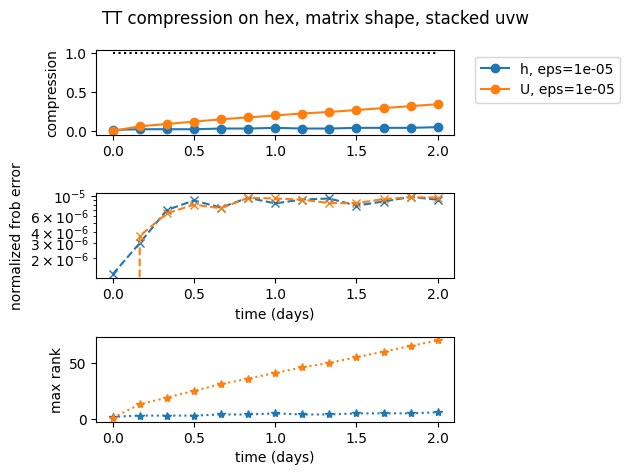

[2. 3. 3. 3. 4. 4. 5. 4. 4. 5. 5. 5. 6.]
[ 1. 13. 19. 25. 31. 36. 41. 46. 50. 55. 60. 65. 70.]


In [56]:
u = uu_edge[:, sorted_inds_u]
v = uu_edge[:, sorted_inds_v]
w = uu_edge[:, sorted_inds_w]

u = u.reshape([u.shape[0]] + mat_shape)
v = v.reshape([v.shape[0]] + mat_shape)
w = w.reshape([w.shape[0]] + mat_shape)
print(u.shape, v.shape, w.shape)
#print(np.all(uu_edge[:, sorted_inds_v[N:2*N]] == v[:, 1, :]))

U = np.ma.zeros([u.shape[0], 3 * u.shape[1], u.shape[2]])
print(U.shape)

U[:, np.arange(3 * u.shape[1]) % 3 == 0, :] = v[:, :, :]
U[:, np.arange(3 * u.shape[1]) % 3 == 1, :] = u[:, :, :]
U[:, np.arange(3 * u.shape[1]) % 3 == 2, :] = w[:, :, :]

eps_h = 1e-5
eps_u = 1e-5
data = [{'var': hh_cell, 'shape': mat_shape, 'eps': eps_h, 'name': 'h'},
        {'var': U.reshape([U.shape[0], U.shape[1] * U.shape[2]]), 'shape': list(U.shape[1:]), 'eps': eps_u, 'name': 'U'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape, stacked uvw',
              f'compression_{mesh_type}_mat_shape_{eps_h}_uvw_stack.png',
              rank=rank)
print(rank[0])
print(rank[1])

(13, 168, 334) (13, 168, 334) (13, 168, 334)
(13, 3, 168, 334)


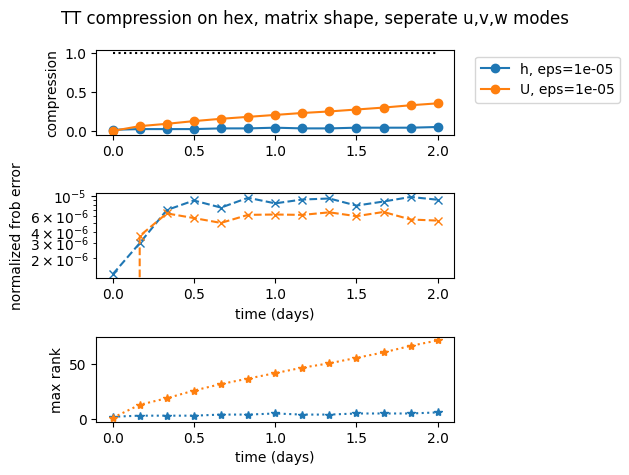

[2. 3. 3. 3. 4. 4. 5. 4. 4. 5. 5. 5. 6.]
[ 1. 13. 19. 26. 32. 37. 42. 47. 51. 56. 61. 67. 72.]


In [58]:
u = uu_edge[:, sorted_inds_u]
v = uu_edge[:, sorted_inds_v]
w = uu_edge[:, sorted_inds_w]

u = u.reshape([u.shape[0]] + mat_shape)
v = v.reshape([v.shape[0]] + mat_shape)
w = w.reshape([w.shape[0]] + mat_shape)
print(u.shape, v.shape, w.shape)

U = np.ma.zeros([u.shape[0], 3,  u.shape[1], u.shape[2]])
print(U.shape)

U[:, 0, :, :] = u[:, :, :]
U[:, 1, :, :] = v[:, :, :]
U[:, 2, :, :] = w[:, :, :]

eps_h = 1e-5
eps_u = 1e-5
data = [{'var': hh_cell, 'shape': mat_shape, 'eps': eps_h, 'name': 'h'},
        {'var': U.reshape([U.shape[0], U.shape[1] * U.shape[2] * U.shape[3]]), 'shape': list(U.shape[1:]), 'eps': eps_u, 'name': 'U'}]

compression, err, rank = get_compression_data(data, get_rank=True)
make_eps_plot(data, compression, err,
              'mpas',
              f'TT compression on {mesh_type}, matrix shape, seperate u,v,w modes',
              f'compression_{mesh_type}_mat_shape_{eps_h}_uvw_modes.png',
              rank=rank)
print(rank[0])
print(rank[1])